In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from utilities import get_git_repo_path, log_bin

# Setup
git_path = get_git_repo_path()
target_frequency = 150929  # MHz
ref_time = 463.7943 # LJ time in fs
ref_temp = 50.3219 # LJ temp in K

In [7]:
all_n = [5] # , 20, 80, 320, 1280]

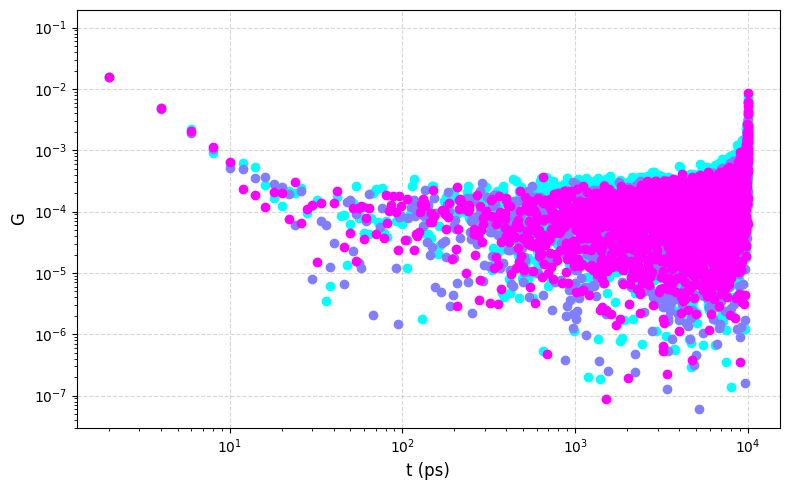

In [21]:
for type in ["full"]:

    fig, ax = plt.subplots(figsize=(8, 5))

    # Colormap and color assignment
    cmap = plt.cm.cool
    colors = cmap(np.linspace(0, 1, 3))

    # Plot each R1 spectrum

    n = all_n[0]

    all_gij_0 = []
    all_gij_1 = []
    all_gij_2 = []

    for repetition in range(10):

        result_file = f"nmr_{type}/result{n}-{repetition}.npy"
        data = np.load(result_file, allow_pickle=True).item()
        t = data["t"]
        gij_0 = data["C"][0]
        gij_1 = data["C"][1]
        gij_2 = data["C"][2]
        all_gij_0.append(gij_0)
        all_gij_1.append(gij_1)
        all_gij_2.append(gij_2)

    mean_gij_0 = np.mean(all_gij_0, axis = 0)
    mean_gij_1 = np.mean(all_gij_1, axis = 0)
    mean_gij_2 = np.mean(all_gij_2, axis = 0)
    std_gij_0 = np.std(all_gij_0, axis = 0)
    std_gij_1 = np.std(all_gij_1, axis = 0)
    std_gij_2 = np.std(all_gij_2, axis = 0)
        
    ax.loglog(t, mean_gij_0, "o", label=f"n = {n:.1f}", color=colors[0])
    ax.loglog(t, 6*mean_gij_1, "o", label=f"n = {n:.1f}", color=colors[1])
    ax.loglog(t, 6/4*mean_gij_2, "o", label=f"n = {n:.1f}", color=colors[2])

    # Axis labels and title
    ax.set_xlabel("t (ps)", fontsize=12)
    ax.set_ylabel("G", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

    # plt.xlim([30, 5e4])
    # plt.ylim([0.005, 3])

    # Colorbar representing temperature gradient
    # norm = plt.Normalize(vmin=0, vmax=1280)
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])

    # cbar = fig.colorbar(sm, ax=ax, label="number_i")

    plt.tight_layout()
    # plt.savefig(f"R1_{type}.png", dpi=300)
    plt.show()

Value of R1 for n = 5 is 0.268 s-1, and T1 is 3.735 s
Value of R2 for n = 5 is 0.268 s-1, and T1 is 3.735 s

Value of R1 for n = 20 is 0.3 s-1, and T1 is 3.33 s
Value of R2 for n = 20 is 0.3 s-1, and T1 is 3.33 s

Value of R1 for n = 80 is 0.234 s-1, and T1 is 4.266 s
Value of R2 for n = 80 is 0.234 s-1, and T1 is 4.266 s

Value of R1 for n = 320 is 0.254 s-1, and T1 is 3.94 s
Value of R2 for n = 320 is 0.254 s-1, and T1 is 3.94 s

Value of R1 for n = 1280 is 0.26 s-1, and T1 is 3.84 s
Value of R2 for n = 1280 is 0.26 s-1, and T1 is 3.84 s



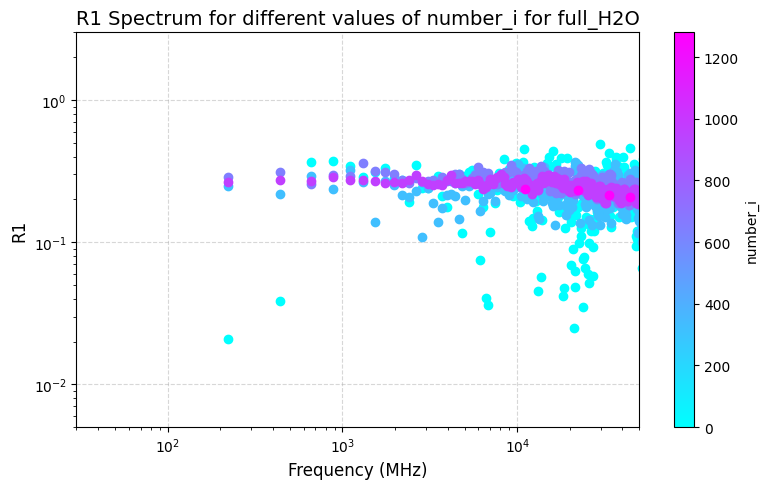